# SIS2: Convolutional Neural Networks Laboratory Report: Dogs vs. Cats Binary Classification
Student 1: Balym Sekenova ID: 23B031433    
Student 2: Nursultan Zhantuar ID: 23B030356  
Student 3: Maxim Abakarov ID: 23B031182   
Student 4: Balzhan Batyrbaeva ID: 23B03124  

## Environment Setup

In [3]:
import os
import time
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

import kagglehub

In [4]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

## Dataset Fetching

In [5]:
# Download latest version
path = kagglehub.dataset_download("tongpython/cat-and-dog")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cat-and-dog' dataset.
Path to dataset files: /kaggle/input/cat-and-dog


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Data Loaders and Sampling

In [7]:
IMG_SIZE = 150
BATCH_SIZE = 32
EPOCHS = 15

TRAIN_DIR = "/kaggle/input/cat-and-dog/training_set/training_set"
VAL_DIR = "/kaggle/input/cat-and-dog/test_set/test_set"

In [8]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(20),
    transforms.RandomHorizontalFlip(),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.9, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [9]:
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=val_transform)

def stratified_sample(dataset, samples_per_class):
    targets = np.array(dataset.targets) # get target var (0,1) - (cats, dogs)
    indices = []

    for class_idx in np.unique(targets): # iterate over (0,1)
        class_indices = np.where(targets == class_idx)[0] # select only cats/dogs
        np.random.shuffle(class_indices) # shuffle
        indices.extend(class_indices[:samples_per_class]) # select only 1000 for train, 400 for test

    return Subset(dataset, indices)

train_sampled = stratified_sample(train_dataset, 1000)
val_sampled   = stratified_sample(val_dataset, 400)

train_loader = DataLoader(train_sampled, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_sampled, batch_size=BATCH_SIZE, shuffle=False)

In [10]:
def count_subset_classes(subset):
    targets = np.array(subset.dataset.targets)
    subset_targets = targets[subset.indices]
    return np.bincount(subset_targets)

print("Train class counts:", count_subset_classes(train_sampled))
print("Val class counts:", count_subset_classes(val_sampled))

Train class counts: [1000 1000]
Val class counts: [400 400]


In [11]:
print(train_dataset.class_to_idx)

{'cats': 0, 'dogs': 1}


## Baseline CNN

### Baseline Model Class

In [12]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 17 * 17, 128),  # computed manually
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

### Training function

In [13]:
def train_model(model, optimizer):
    model.to(device)
    criterion = nn.BCEWithLogitsLoss()

    train_acc_list, val_acc_list = [], []
    train_loss_list, val_loss_list = [], []

    start_time = time.time()

    for epoch in range(EPOCHS):
        model.train()
        correct, total, running_loss = 0, 0, 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            preds = torch.sigmoid(outputs) > 0.5
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = correct / total
        train_loss = running_loss / len(train_loader)

        # Validation
        model.eval()
        correct, total, running_loss = 0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.float().unsqueeze(1).to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_loss += loss.item()
                preds = torch.sigmoid(outputs) > 0.5
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_acc = correct / total
        val_loss = running_loss / len(val_loader)

        train_acc_list.append(train_acc)
        val_acc_list.append(val_acc)
        train_loss_list.append(train_loss)
        val_loss_list.append(val_loss)

        print(f"Epoch {epoch+1}/{EPOCHS} | "
              f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    total_time = time.time() - start_time
    print("Training time:", total_time, "seconds")

    return train_acc_list, val_acc_list, train_loss_list, val_loss_list

In [14]:
def plot_history(train_acc, val_acc, train_loss, val_loss, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(train_acc, label='train')
    axes[0].plot(val_acc, label='val')
    axes[0].set_title("Accuracy " + title)
    axes[0].legend()

    axes[1].plot(train_loss, label='train')
    axes[1].plot(val_loss, label='val')
    axes[1].set_title("Loss " + title)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

In [15]:
models_metrics = dict()

Epoch 1/15 | Train Acc: 0.5075 | Val Acc: 0.5962
Epoch 2/15 | Train Acc: 0.5770 | Val Acc: 0.6088
Epoch 3/15 | Train Acc: 0.6160 | Val Acc: 0.6462
Epoch 4/15 | Train Acc: 0.6475 | Val Acc: 0.6375
Epoch 5/15 | Train Acc: 0.6705 | Val Acc: 0.6325
Epoch 6/15 | Train Acc: 0.6850 | Val Acc: 0.6913
Epoch 7/15 | Train Acc: 0.6965 | Val Acc: 0.7063
Epoch 8/15 | Train Acc: 0.7120 | Val Acc: 0.6725
Epoch 9/15 | Train Acc: 0.7180 | Val Acc: 0.6950
Epoch 10/15 | Train Acc: 0.7395 | Val Acc: 0.6937
Epoch 11/15 | Train Acc: 0.7385 | Val Acc: 0.7100
Epoch 12/15 | Train Acc: 0.7530 | Val Acc: 0.6900
Epoch 13/15 | Train Acc: 0.7410 | Val Acc: 0.6713
Epoch 14/15 | Train Acc: 0.7635 | Val Acc: 0.7250
Epoch 15/15 | Train Acc: 0.7800 | Val Acc: 0.7288
Training time: 205.64303421974182 seconds


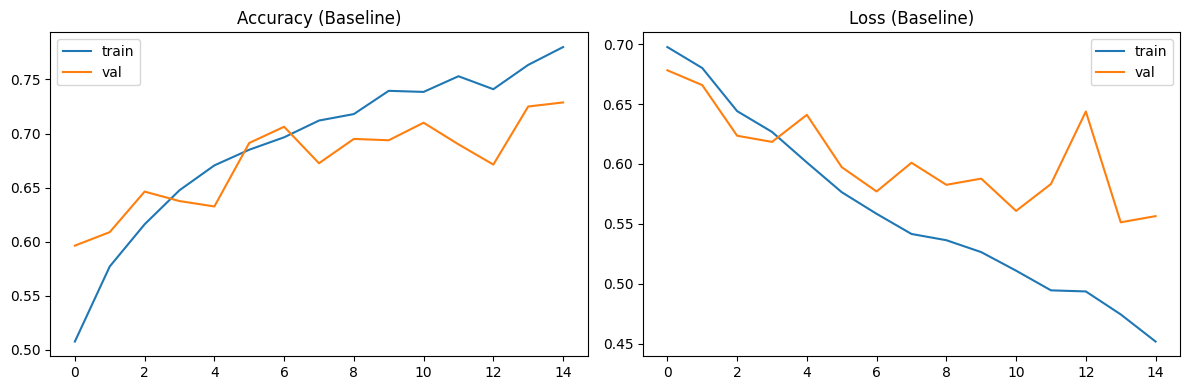

In [16]:
model = BaselineCNN()
optimizer = optim.Adam(model.parameters())

train_acc, val_acc, train_loss, val_loss = train_model(model, optimizer)
models_metrics["baseline"] = {
    "train_acc" : train_acc,
    "val_acc" : val_acc,
    "train_loss" : train_loss,
    "val_loss" : val_loss
}
plot_history(train_acc, val_acc, train_loss, val_loss, "(Baseline)")

## Experiment A

In [17]:
class ModelA(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 8, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(8, 16, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 17 * 17, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [18]:
model_A = ModelA()
optimizer_A = optim.Adam(model_A.parameters())

train_acc_a, val_acc_a, train_loss_a, val_loss_a = train_model(model_A, optimizer_A)
models_metrics["model_A"] = {
    "train_acc" : train_acc_a,
    "val_acc" : val_acc_a,
    "train_loss" : train_loss_a,
    "val_loss" : val_loss_a
}

Epoch 1/15 | Train Acc: 0.5340 | Val Acc: 0.5000
Epoch 2/15 | Train Acc: 0.5760 | Val Acc: 0.5563
Epoch 3/15 | Train Acc: 0.6340 | Val Acc: 0.6288
Epoch 4/15 | Train Acc: 0.6440 | Val Acc: 0.6488
Epoch 5/15 | Train Acc: 0.6780 | Val Acc: 0.6375
Epoch 6/15 | Train Acc: 0.6950 | Val Acc: 0.6900
Epoch 7/15 | Train Acc: 0.7205 | Val Acc: 0.6887
Epoch 8/15 | Train Acc: 0.7255 | Val Acc: 0.7125
Epoch 9/15 | Train Acc: 0.7415 | Val Acc: 0.6575
Epoch 10/15 | Train Acc: 0.7390 | Val Acc: 0.7188
Epoch 11/15 | Train Acc: 0.7450 | Val Acc: 0.7362
Epoch 12/15 | Train Acc: 0.7550 | Val Acc: 0.7275
Epoch 13/15 | Train Acc: 0.7540 | Val Acc: 0.7200
Epoch 14/15 | Train Acc: 0.7695 | Val Acc: 0.7375
Epoch 15/15 | Train Acc: 0.7570 | Val Acc: 0.7338
Training time: 167.70062828063965 seconds


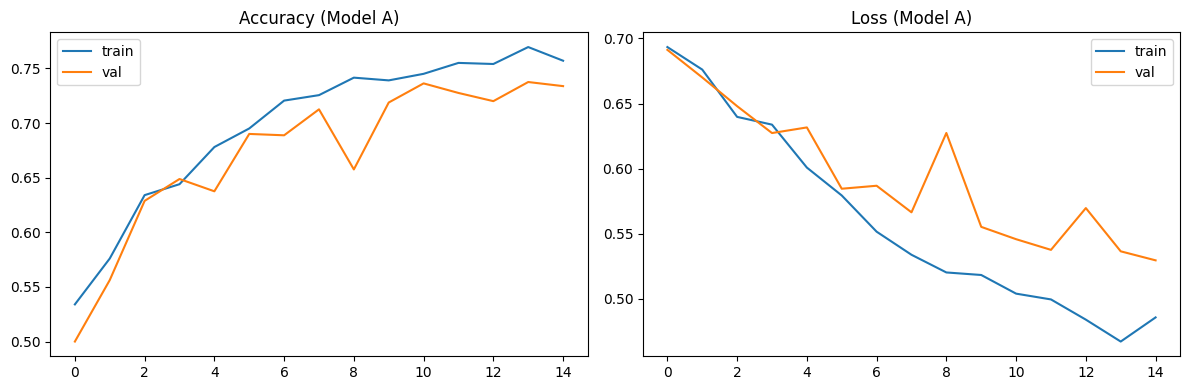

In [19]:
plot_history(train_acc_a, val_acc_a, train_loss_a, val_loss_a, "(Model A)")

## Experiment B

In [20]:
class ModelB(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2),
            nn.ReLU(),

            nn.Conv2d(32, 64, 3, stride=2),
            nn.ReLU(),

            nn.Conv2d(64, 128, 3, stride=2),
            nn.ReLU()
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 17 * 17, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [21]:
model_B = ModelB()
optimizer_B = optim.Adam(model_B.parameters())

train_acc_b, val_acc_b, train_loss_b, val_loss_b = train_model(model_B, optimizer_B)
models_metrics["model_B"] = {
    "train_acc" : train_acc_b,
    "val_acc" : val_acc_b,
    "train_loss" : train_loss_b,
    "val_loss" : val_loss_b
}

Epoch 1/15 | Train Acc: 0.5520 | Val Acc: 0.6125
Epoch 2/15 | Train Acc: 0.6015 | Val Acc: 0.6350
Epoch 3/15 | Train Acc: 0.6455 | Val Acc: 0.6112
Epoch 4/15 | Train Acc: 0.6575 | Val Acc: 0.6050
Epoch 5/15 | Train Acc: 0.6675 | Val Acc: 0.6687
Epoch 6/15 | Train Acc: 0.6885 | Val Acc: 0.6600
Epoch 7/15 | Train Acc: 0.7015 | Val Acc: 0.6700
Epoch 8/15 | Train Acc: 0.7205 | Val Acc: 0.6763
Epoch 9/15 | Train Acc: 0.7110 | Val Acc: 0.6925
Epoch 10/15 | Train Acc: 0.7195 | Val Acc: 0.7037
Epoch 11/15 | Train Acc: 0.7440 | Val Acc: 0.7275
Epoch 12/15 | Train Acc: 0.7565 | Val Acc: 0.7037
Epoch 13/15 | Train Acc: 0.7545 | Val Acc: 0.7238
Epoch 14/15 | Train Acc: 0.7660 | Val Acc: 0.7087
Epoch 15/15 | Train Acc: 0.7690 | Val Acc: 0.7150
Training time: 169.28773069381714 seconds


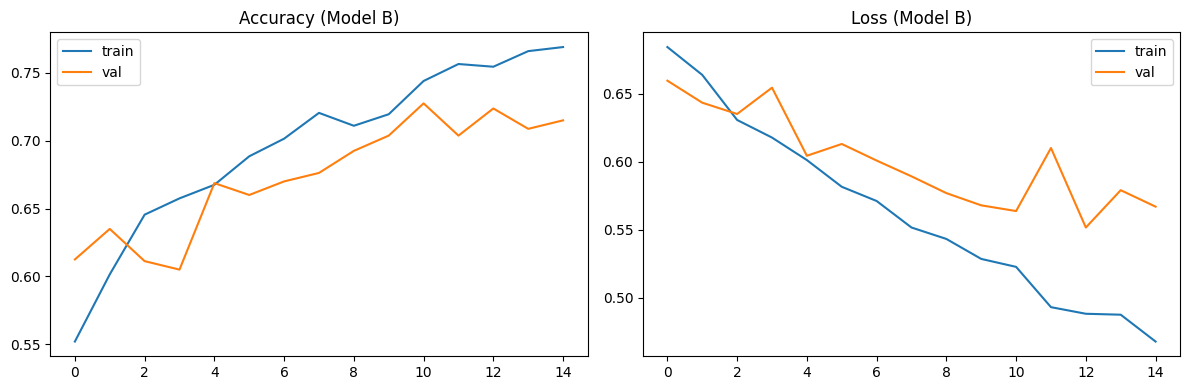

In [22]:
plot_history(train_acc_b, val_acc_b, train_loss_b, val_loss_b, "(Model B)")

## Experiment C

In [23]:
class ModelC(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 17 * 17, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [24]:
model_C = ModelC()
optimizer_C = optim.Adam(model_C.parameters())

train_acc_c, val_acc_c, train_loss_c, val_loss_c = train_model(model_C, optimizer_C)
models_metrics["model_C"] = {
    "train_acc" : train_acc_c,
    "val_acc" : val_acc_c,
    "train_loss" : train_loss_c,
    "val_loss" : val_loss_c
}

Epoch 1/15 | Train Acc: 0.5105 | Val Acc: 0.5000
Epoch 2/15 | Train Acc: 0.5450 | Val Acc: 0.5563
Epoch 3/15 | Train Acc: 0.6300 | Val Acc: 0.6188
Epoch 4/15 | Train Acc: 0.6610 | Val Acc: 0.6825
Epoch 5/15 | Train Acc: 0.6805 | Val Acc: 0.6700
Epoch 6/15 | Train Acc: 0.6980 | Val Acc: 0.6963
Epoch 7/15 | Train Acc: 0.7185 | Val Acc: 0.7113
Epoch 8/15 | Train Acc: 0.7385 | Val Acc: 0.7312
Epoch 9/15 | Train Acc: 0.7500 | Val Acc: 0.6800
Epoch 10/15 | Train Acc: 0.7485 | Val Acc: 0.7312
Epoch 11/15 | Train Acc: 0.7825 | Val Acc: 0.7113
Epoch 12/15 | Train Acc: 0.7650 | Val Acc: 0.6950
Epoch 13/15 | Train Acc: 0.7825 | Val Acc: 0.7388
Epoch 14/15 | Train Acc: 0.7890 | Val Acc: 0.7262
Epoch 15/15 | Train Acc: 0.8030 | Val Acc: 0.7087
Training time: 186.4713170528412 seconds


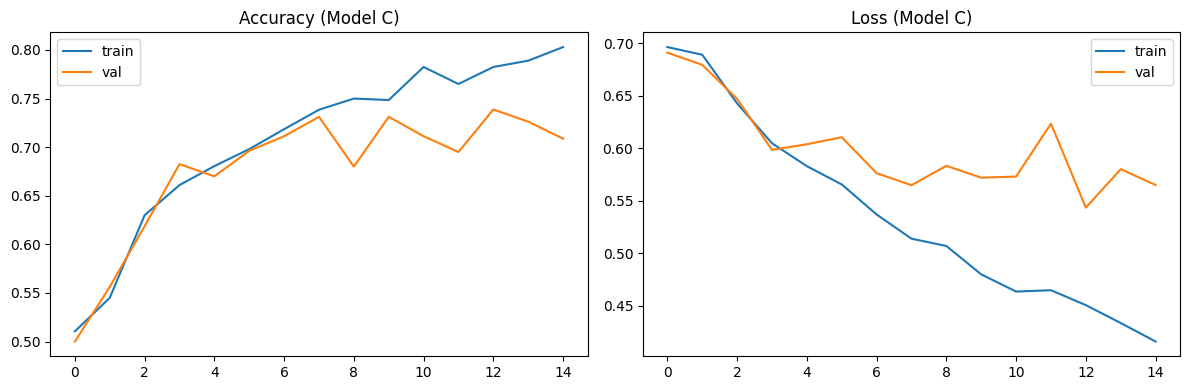

In [25]:
plot_history(train_acc_c, val_acc_c, train_loss_c, val_loss_c, "(Model C)")

## Experiment D

In [26]:
model_D = BaselineCNN()
optimizer_D = optim.SGD(model_D.parameters(), lr=0.01)

train_acc_d, val_acc_d, train_loss_d, val_loss_d = train_model(model_D, optimizer_D)
models_metrics["model_D"] = {
    "train_acc" : train_acc_d,
    "val_acc" : val_acc_d,
    "train_loss" : train_loss_d,
    "val_loss" : val_loss_d
}

Epoch 1/15 | Train Acc: 0.5130 | Val Acc: 0.5938
Epoch 2/15 | Train Acc: 0.5500 | Val Acc: 0.5975
Epoch 3/15 | Train Acc: 0.5530 | Val Acc: 0.5625
Epoch 4/15 | Train Acc: 0.5455 | Val Acc: 0.5938
Epoch 5/15 | Train Acc: 0.5560 | Val Acc: 0.5787
Epoch 6/15 | Train Acc: 0.5885 | Val Acc: 0.5637
Epoch 7/15 | Train Acc: 0.5800 | Val Acc: 0.5875
Epoch 8/15 | Train Acc: 0.5680 | Val Acc: 0.5863
Epoch 9/15 | Train Acc: 0.5890 | Val Acc: 0.5900
Epoch 10/15 | Train Acc: 0.6065 | Val Acc: 0.5962
Epoch 11/15 | Train Acc: 0.5810 | Val Acc: 0.6012
Epoch 12/15 | Train Acc: 0.6000 | Val Acc: 0.6100
Epoch 13/15 | Train Acc: 0.6125 | Val Acc: 0.6100
Epoch 14/15 | Train Acc: 0.6100 | Val Acc: 0.6200
Epoch 15/15 | Train Acc: 0.6150 | Val Acc: 0.5875
Training time: 184.80421924591064 seconds


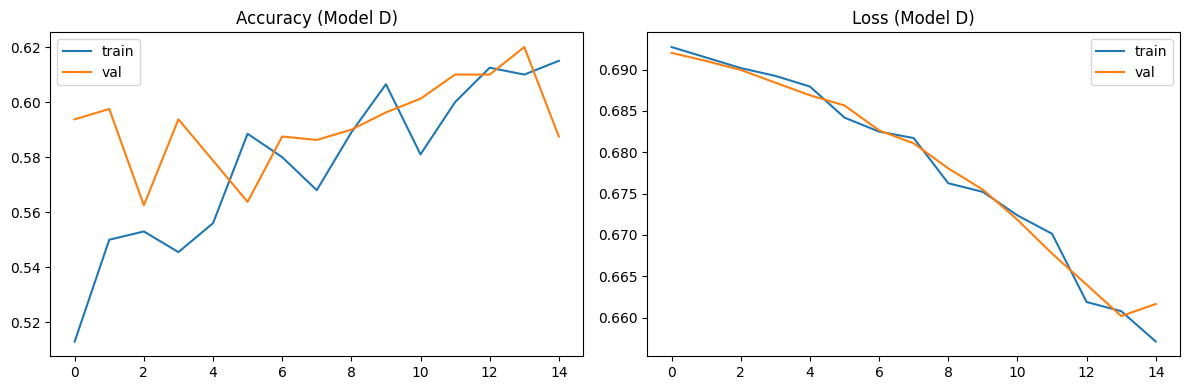

In [27]:
plot_history(train_acc_d, val_acc_d, train_loss_d, val_loss_d, "(Model D)")

## Experiment E

In [28]:
class ModelE(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [29]:
model_E = ModelE()
optimizer_E = optim.Adam(model_E.parameters())

train_acc_e, val_acc_e, train_loss_e, val_loss_e = train_model(model_E, optimizer_E)
models_metrics["model_E"] = {
    "train_acc" : train_acc_e,
    "val_acc" : val_acc_e,
    "train_loss" : train_loss_e,
    "val_loss" : val_loss_e
}

Epoch 1/15 | Train Acc: 0.5135 | Val Acc: 0.5012
Epoch 2/15 | Train Acc: 0.5295 | Val Acc: 0.4988
Epoch 3/15 | Train Acc: 0.5680 | Val Acc: 0.5375
Epoch 4/15 | Train Acc: 0.6055 | Val Acc: 0.6325
Epoch 5/15 | Train Acc: 0.6535 | Val Acc: 0.6462
Epoch 6/15 | Train Acc: 0.6805 | Val Acc: 0.6837
Epoch 7/15 | Train Acc: 0.7000 | Val Acc: 0.6875
Epoch 8/15 | Train Acc: 0.7050 | Val Acc: 0.6950
Epoch 9/15 | Train Acc: 0.7105 | Val Acc: 0.7050
Epoch 10/15 | Train Acc: 0.7195 | Val Acc: 0.6950
Epoch 11/15 | Train Acc: 0.7415 | Val Acc: 0.7113
Epoch 12/15 | Train Acc: 0.7420 | Val Acc: 0.7325
Epoch 13/15 | Train Acc: 0.7660 | Val Acc: 0.7137
Epoch 14/15 | Train Acc: 0.7725 | Val Acc: 0.7475
Epoch 15/15 | Train Acc: 0.7745 | Val Acc: 0.7087
Training time: 188.89886689186096 seconds


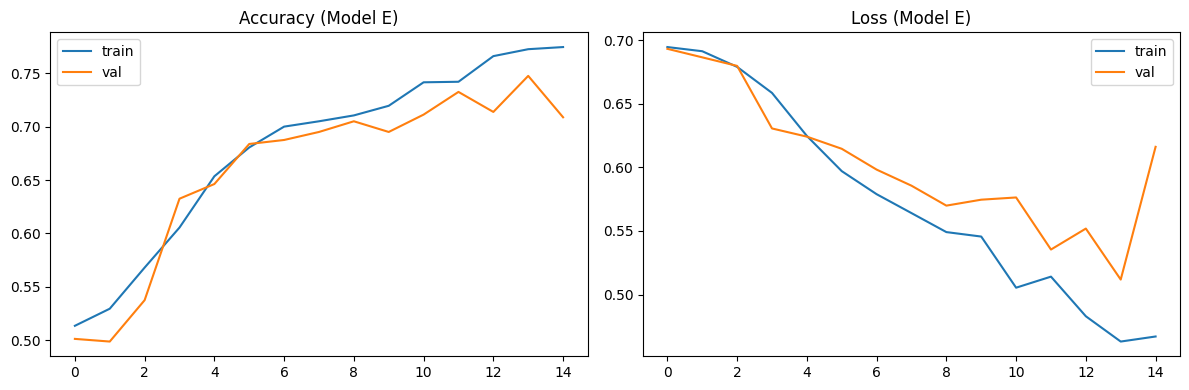

In [30]:
plot_history(train_acc_e, val_acc_e, train_loss_e, val_loss_e, "(Model E)")

## Experiment Results Analysis

In [31]:
models_metrics

{'baseline': {'train_acc': [0.5075,
   0.577,
   0.616,
   0.6475,
   0.6705,
   0.685,
   0.6965,
   0.712,
   0.718,
   0.7395,
   0.7385,
   0.753,
   0.741,
   0.7635,
   0.78],
  'val_acc': [0.59625,
   0.60875,
   0.64625,
   0.6375,
   0.6325,
   0.69125,
   0.70625,
   0.6725,
   0.695,
   0.69375,
   0.71,
   0.69,
   0.67125,
   0.725,
   0.72875],
  'train_loss': [0.6974826142901466,
   0.6800051624812777,
   0.6440756604785011,
   0.6267549234723288,
   0.6012693444887797,
   0.5764880118862031,
   0.5584595903517708,
   0.5416629177237314,
   0.536450323604402,
   0.5265333728184776,
   0.5110517456417992,
   0.4946545343550425,
   0.4937416859089382,
   0.47460211695186677,
   0.45196757808564203],
  'val_loss': [0.678111264705658,
   0.665768928527832,
   0.6235493111610413,
   0.61842644572258,
   0.6409726464748382,
   0.5973568058013916,
   0.5770945489406586,
   0.6010380184650421,
   0.5826508915424347,
   0.5877899312973023,
   0.5609013986587524,
   0.583320949077

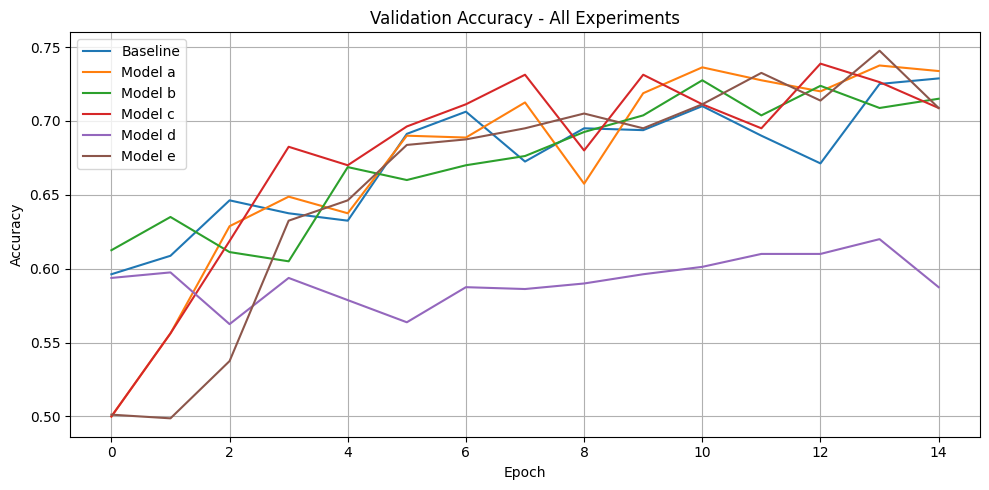

In [32]:
plt.figure(figsize=(10, 5))
for name, metrics in models_metrics.items():
    val_acc = metrics["val_acc"]
    plt.plot(val_acc, label=" ".join(name.split("_")).capitalize())
plt.title('Validation Accuracy - All Experiments')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
